In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score
)

le = LabelEncoder()

df = pd.read_csv('credit_card.csv')

df["merchant_category"] = le.fit_transform(df["merchant_category"])

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,1,0,0,66,3,40,0
1,2,541.82,3,4,1,0,87,1,64,0
2,3,237.01,17,3,0,0,49,1,61,0
3,4,164.33,4,3,0,1,72,3,34,0
4,5,30.53,15,2,0,0,79,0,44,0


In [19]:
scaler = RobustScaler()  # Robust to outliers
# Create feature engineering variables (drop categorical columns)
X = df.drop('is_fraud', axis=1).copy()
y = df['is_fraud'].copy()



X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.describe())

       transaction_id        amount  transaction_hour  merchant_category  \
count    10000.000000  10000.000000      10000.000000       10000.000000   
mean         0.000000      0.281116         -0.033892          -0.004950   
std          0.577437      0.915531          0.576892           0.707602   
min         -1.000000     -0.637322         -1.000000          -1.000000   
25%         -0.500000     -0.371604         -0.500000          -0.500000   
50%          0.000000      0.000000          0.000000           0.000000   
75%          0.500000      0.628396          0.500000           0.500000   
max          1.000000      7.041342          0.916667           1.000000   

       foreign_transaction  location_mismatch  device_trust_score  \
count         10000.000000       10000.000000        10000.000000   
mean              0.097800           0.085700           -0.005435   
std               0.297059           0.279935            0.580731   
min               0.000000           0.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

model = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric='logloss'
    )

model.fit(X_train, y_train)
    
    # Predictions
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [21]:
# Отримуємо ймовірності передбачень
y_pred_proba = model.predict_proba(X_test)[:, 1]  # ймовірність класу 1 (fraud)

# Створюємо DataFrame з результатами
results = pd.DataFrame({
    'Фактичне значення (Actual)': y_test.values[:100],
    'Передбачення (Prediction)': y_pred[:100],
    'Ймовірність шахрайства (Fraud Probability)': y_pred_proba[:100]
})

# Додаємо оригінальні дані
results_display = pd.concat([
    X_test.iloc[:100].reset_index(drop=True),
    results
], axis=1)

print("Перші 5 елементів з передбаченнями:")
print("=" * 80)
display(results_display)

# Показуємо також статус правильності передбачення
results['Правильність'] = (results['Фактичне значення (Actual)'] == results['Передбачення (Prediction)']).map({True: '✅ Правильно', False: '❌ Неправильно'})
print("\nДетальні результати:")
print(results[['Фактичне значення (Actual)', 'Передбачення (Prediction)', 'Ймовірність шахрайства (Fraud Probability)', 'Правильність']])



Перші 5 елементів з передбаченнями:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,Фактичне значення (Actual),Передбачення (Prediction),Ймовірність шахрайства (Fraud Probability)
0,-0.370337,0.817408,0.000000,0.0,1.0,1.0,0.702703,0.0,0.769231,0,0,4.982454e-03
1,-0.214721,0.231946,0.500000,-0.5,0.0,0.0,0.324324,1.0,-0.576923,0,0,5.918593e-07
2,-0.893189,0.739423,-0.416667,-1.0,0.0,0.0,-0.729730,-0.5,-0.038462,0,0,2.674200e-06
3,0.147515,-0.346627,0.083333,0.0,0.0,0.0,-0.378378,-0.5,0.346154,0,0,4.050811e-07
4,-0.365337,-0.473000,0.166667,0.5,0.0,0.0,-0.837838,-0.5,0.923077,0,0,2.660314e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.179518,0.109070,-0.833333,0.0,0.0,0.0,-0.729730,0.0,0.615385,0,0,7.803434e-04
96,0.891789,0.385045,-0.416667,0.0,0.0,0.0,-0.108108,0.0,0.115385,0,0,5.633591e-07
97,-0.095710,0.171343,-0.750000,-1.0,0.0,0.0,-0.972973,0.5,-0.884615,0,0,1.314122e-03
98,-0.931193,-0.159702,0.583333,1.0,0.0,0.0,-0.486486,0.0,0.538462,0,0,9.818708e-07



Детальні результати:
    Фактичне значення (Actual)  Передбачення (Prediction)  \
0                            0                          0   
1                            0                          0   
2                            0                          0   
3                            0                          0   
4                            0                          0   
..                         ...                        ...   
95                           0                          0   
96                           0                          0   
97                           0                          0   
98                           0                          0   
99                           0                          0   

    Ймовірність шахрайства (Fraud Probability) Правильність  
0                                 4.982454e-03  ✅ Правильно  
1                                 5.918593e-07  ✅ Правильно  
2                                 2.674200e-06  ✅ Правильно

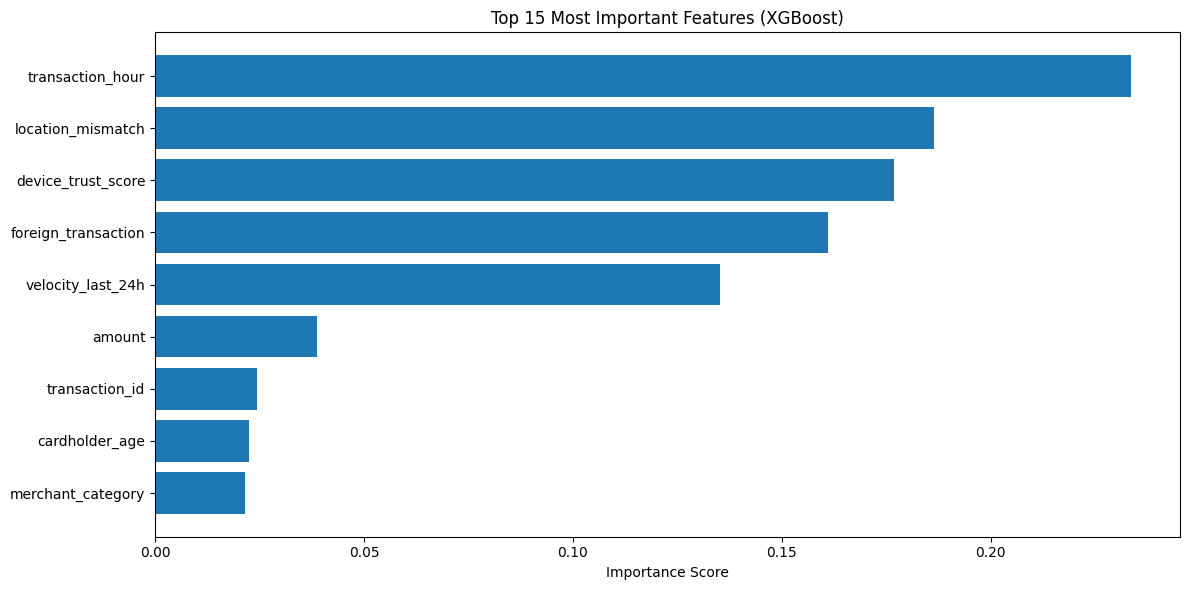

Top 15 Most Important Features:
               feature  importance
2     transaction_hour    0.233579
5    location_mismatch    0.186303
6   device_trust_score    0.176804
4  foreign_transaction    0.161036
7    velocity_last_24h    0.135117
1               amount    0.038701
0       transaction_id    0.024449
8       cardholder_age    0.022417
3    merchant_category    0.021596


In [22]:

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 15 Most Important Features:")
print(feature_importance.head(15))